In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [18]:
# Create dataset with real data from Eurostat and World Bank

countries = ["Portugal", "Spain", "France", "Germany", "Italy", "Netherlands"]
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

data = []
for country in countries:
    for year in years:
        data.append({"country": country, "year": year})

df = pd.DataFrame(data)

# GDP per capita (World Bank, current US$)
gdp_values = {
    "Portugal": [19216, 19980, 21442, 23541, 23343, 22299, 24711, 24621],
    "Spain": [25982, 26756, 28381, 30602, 29787, 27234, 30799, 30319],
    "France": [36702, 37024, 38687, 41418, 40408, 39170, 43725, 40989],
    "Germany": [41930, 42949, 45554, 48916, 47656, 47395, 52349, 50507],
    "Italy": [30640, 31392, 32844, 34904, 33813, 32091, 36853, 35654],
    "Netherlands": [45794, 46809, 49514, 53955, 53555, 53468, 60142, 59123]
}

# Gini index (World Bank)
gini_values = {
    "Portugal": [35.5, 35.2, 33.8, 33.5, 32.8, 34.7, 34.6, 36.3],
    "Spain": [36.2, 35.8, 34.7, 34.7, 34.3, 34.9, 33.9, 33.6],
    "France": [32.7, 31.9, 31.6, 32.4, 31.2, 30.7, 31.5, 31.2],
    "Germany": [31.4, 31.3, 31.3, 31.9, 32.2, 32.5, 33.6, 33.7],
    "Italy": [35.4, 35.2, 35.9, 35.2, 34.6, 35.2, 34.8, 33.7],
    "Netherlands": [28.2, 28.2, 28.5, 28.1, 29.2, 26.0, 25.7, np.nan]
}

# Urban population % (World Bank)
urban_values = {
    "Portugal": [61.1, 61.1, 61.1, 61.1, 61.1, 61.1, 61.1, 61.1],
    "Spain": [79.2, 79.4, 79.5, 79.6, 79.6, 79.7, 79.8, 80.0],
    "France": [77.8, 78.6, 78.6, 78.7, 78.7, 78.7, 78.7, 78.8],
    "Germany": [80.7, 80.8, 81.0, 81.1, 81.3, 81.5, 81.6, 81.8],
    "Italy": [69.6, 69.6, 69.5, 69.5, 69.5, 69.5, 69.5, 69.5],
    "Netherlands": [90.3, 90.6, 91.1, 92.6, 93.9, 94.3, 94.6, 95.0]
}

# Crime rate - intentional homicide per 100k (Eurostat)
crime_values = {
    "Portugal": [1.0, 1.0, 0.9, 0.8, 0.9, 0.9, 0.8, 0.8],
    "Spain": [0.7, 0.7, 0.7, 0.6, 0.7, 0.6, 0.6, 0.7],
    "France": [1.6, 1.5, 1.4, 1.2, 1.3, 1.3, 1.2, 1.6],
    "Germany": [0.8, 0.9, 0.9, 1.0, 0.9, 0.9, 0.9, 0.8],
    "Italy": [0.8, 0.8, 0.7, 0.6, 0.6, 0.5, 0.6, 0.6],
    "Netherlands": [0.6, 0.6, 0.7, 0.6, 0.7, 0.6, 0.6, 0.8]
}

# Unemployment rate % (Eurostat)
unemp_values = {
    "Portugal": [13.0, 11.5, 9.2, 7.2, 6.6, 7.1, 6.7, 6.2],
    "Spain": [22.1, 19.6, 17.2, 15.3, 14.1, 15.5, 14.9, 13.0],
    "France": [10.3, 10.1, 9.4, 9.0, 8.4, 8.0, 7.9, 7.3],
    "Germany": [4.4, 3.9, 3.5, 3.2, 2.9, 3.6, 3.6, 3.1],
    "Italy": [12.0, 11.7, 11.3, 10.6, 9.9, 9.3, 9.5, 8.1],
    "Netherlands": [7.9, 7.0, 5.9, 4.9, 4.4, 4.9, 4.2, 3.5]
}

# Fill dataframe
def fill_column(df, values_dict, column_name):
    df[column_name] = np.nan
    for country in countries:
        vals = values_dict[country]
        for i, year in enumerate(years):
            df.loc[(df["country"] == country) & (df["year"] == year), column_name] = vals[i]
    return df

df = fill_column(df, gdp_values, "gdp_per_capita")
df = fill_column(df, gini_values, "gini")
df = fill_column(df, urban_values, "urban_population")
df = fill_column(df, crime_values, "crime_rate")
df = fill_column(df, unemp_values, "unemployment")

print("Dataset created successfully.")
print(f"Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Countries: {df['country'].unique().tolist()}")
print(f"Years: {df['year'].unique().tolist()}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset created successfully.
Dimensions: 48 rows x 7 columns
Countries: ['Portugal', 'Spain', 'France', 'Germany', 'Italy', 'Netherlands']
Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

Missing values per column:
country             0
year                0
gdp_per_capita      0
gini                1
urban_population    0
crime_rate          0
unemployment        0
dtype: int64


VISUALIZATION 1: Crime Rate by Country
Average crime rate by country:
country
France        1.39
Germany       0.89
Portugal      0.89
Spain         0.66
Netherlands   0.65
Italy         0.65
Name: crime_rate, dtype: float64


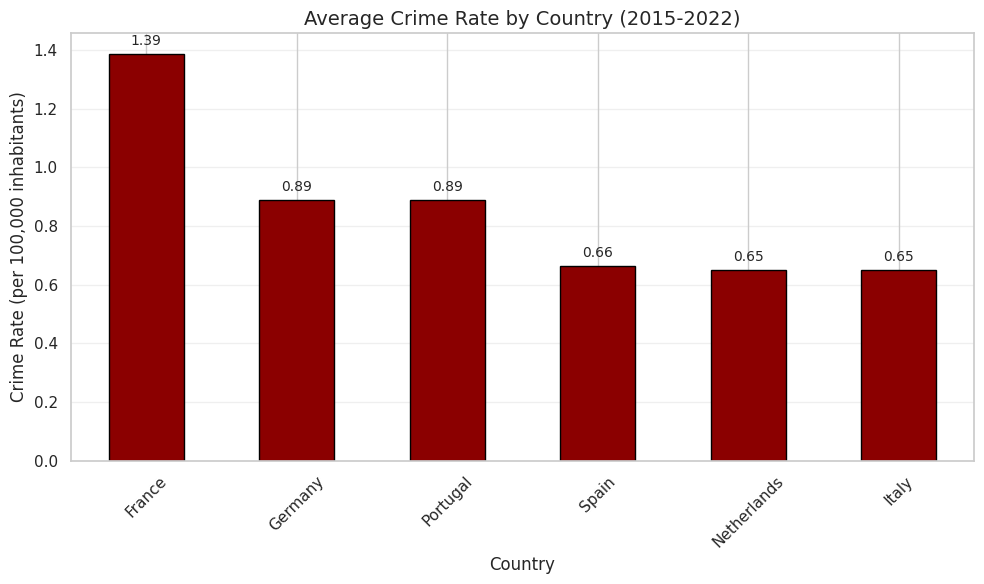

Saved: crime_by_country.png

VISUALIZATION 2: Crime Rate Over Time


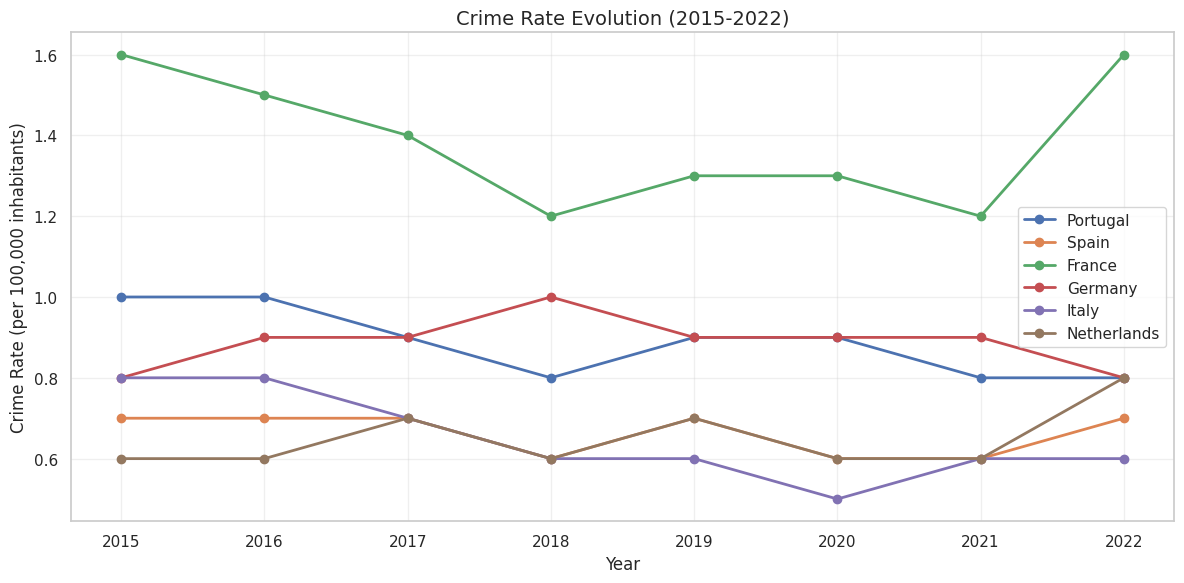

Saved: crime_over_time.png

VISUALIZATION 3: Crime vs Unemployment


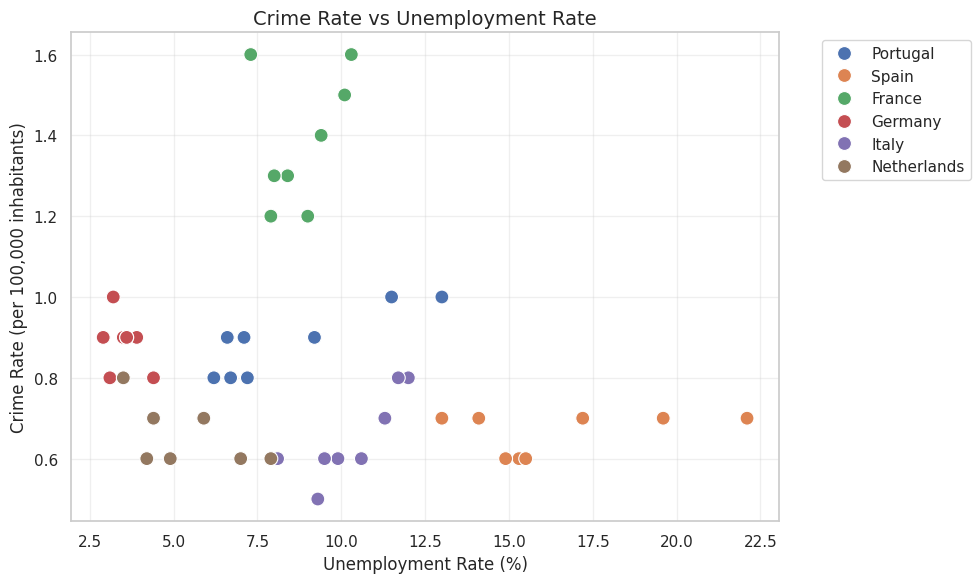

Saved: crime_vs_unemployment.png

VISUALIZATION 4: Correlation Matrix
Correlation Matrix:
                  gdp_per_capita  gini  urban_population  crime_rate  \
gdp_per_capita              1.00 -0.79              0.83        0.01   
gini                       -0.79  1.00             -0.76       -0.07   
urban_population            0.83 -0.76              1.00       -0.10   
crime_rate                  0.01 -0.07             -0.10        1.00   
unemployment               -0.65  0.57             -0.21       -0.14   

                  unemployment  
gdp_per_capita           -0.65  
gini                      0.57  
urban_population         -0.21  
crime_rate               -0.14  
unemployment              1.00  


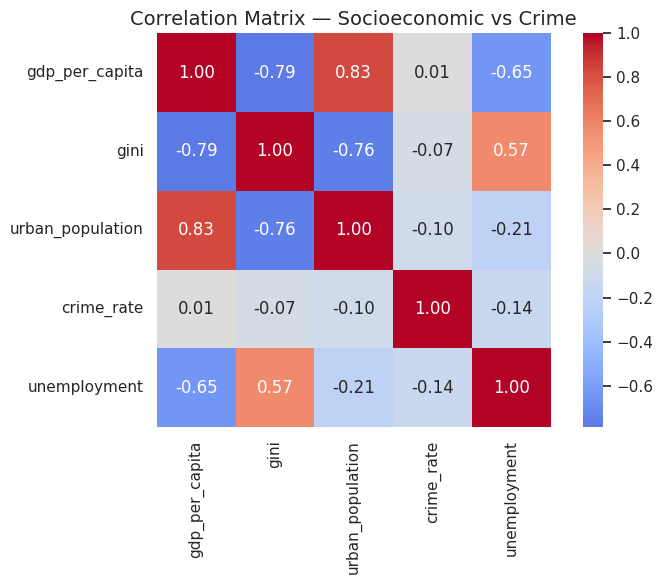

Saved: correlation_matrix.png

VISUALIZATION 5: GDP per Capita vs Crime


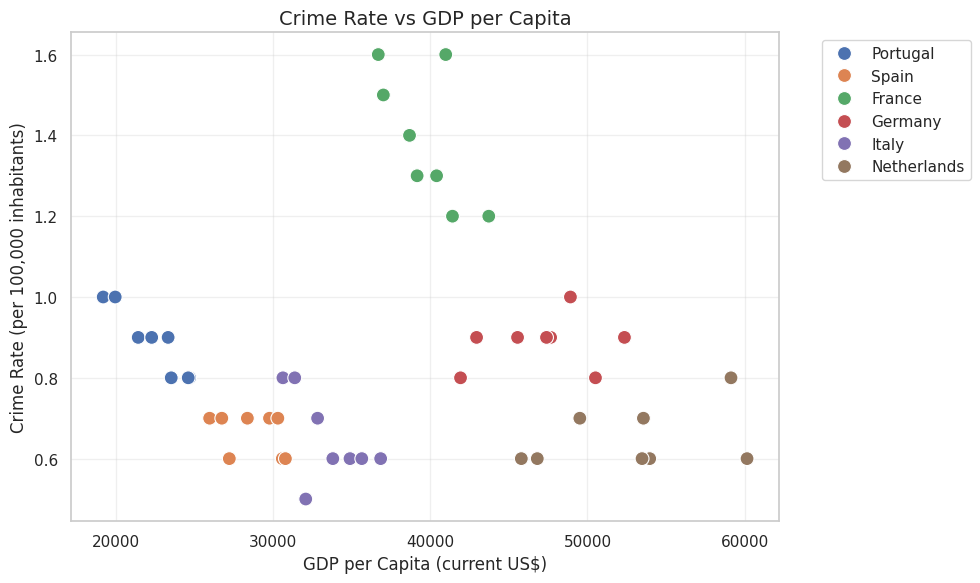

Saved: crime_vs_gdp.png

REGRESSION ANALYSIS
                            OLS Regression Results                            
Dep. Variable:             crime_rate   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.6657
Date:                Tue, 30 Jun 2026   Prob (F-statistic):              0.519
Time:                        00:04:26   Log-Likelihood:                -5.6341
No. Observations:                  48   AIC:                             17.27
Df Residuals:                      45   BIC:                             22.88
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

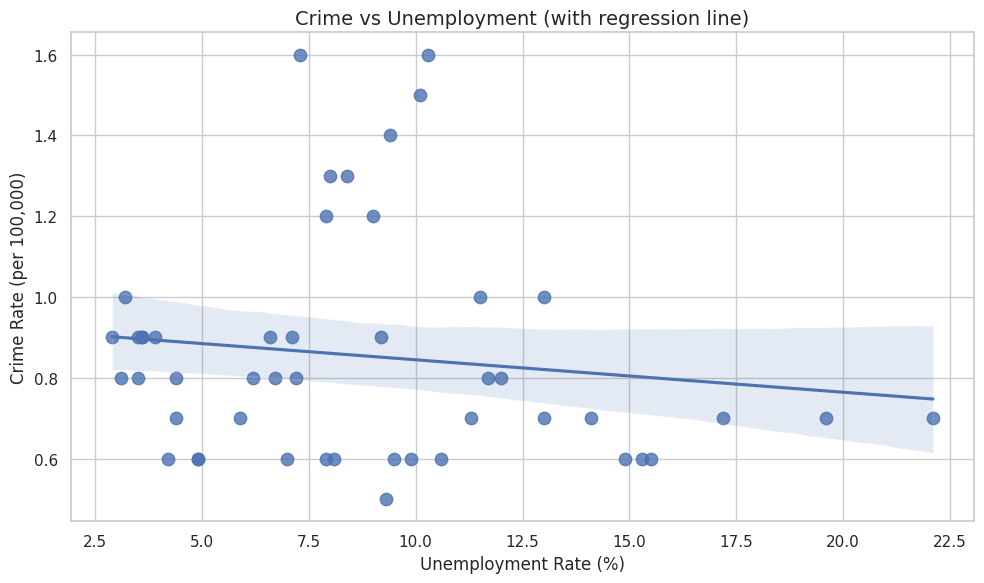


SUMMARY STATISTICS
       gdp_per_capita  gini  urban_population  crime_rate  unemployment
count           48.00 47.00             48.00       48.00         48.00
mean         37394.65 32.76             77.14        0.85          8.81
std          10947.20  2.67             10.01        0.28          4.51
min          19216.00 25.70             61.10        0.50          2.90
25%          29435.50 31.35             69.50        0.60          4.90
50%          36777.50 33.60             79.00        0.80          8.05
75%          46047.75 34.75             81.15        0.90         11.35
max          60142.00 36.30             95.00        1.60         22.10

ANALYSIS COMPLETE
Generated files:
  - crime_by_country.png
  - crime_over_time.png
  - crime_vs_unemployment.png
  - correlation_matrix.png
  - crime_vs_gdp.png
  - regression_results.txt


In [19]:
# ============================================================
# VISUALIZATION 1: Crime Rate by Country (Bar Chart)
# ============================================================

print("="*60)
print("VISUALIZATION 1: Crime Rate by Country")
print("="*60)

crime_by_country = df.groupby("country")["crime_rate"].mean().sort_values(ascending=False)

print("Average crime rate by country:")
print(crime_by_country)

plt.figure(figsize=(10, 6))
bars = crime_by_country.plot(kind="bar", color="darkred", edgecolor="black")
plt.title("Average Crime Rate by Country (2015-2022)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for bar in bars.patches:
    height = bar.get_height()
    if not pd.isna(height):
        bars.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("crime_by_country.png", dpi=150)
plt.show()
print("Saved: crime_by_country.png")

# ============================================================
# VISUALIZATION 2: Crime Rate Over Time (Line Plot)
# ============================================================

print("\n" + "="*60)
print("VISUALIZATION 2: Crime Rate Over Time")
print("="*60)

plt.figure(figsize=(12, 6))

for country in countries:
    data = df[df['country'] == country].sort_values('year')
    plt.plot(data['year'], data['crime_rate'], marker='o', label=country, linewidth=2)

plt.title("Crime Rate Evolution (2015-2022)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crime_over_time.png", dpi=150)
plt.show()
print("Saved: crime_over_time.png")

# ============================================================
# VISUALIZATION 3: Crime vs Unemployment (Scatter Plot)
# ============================================================

print("\n" + "="*60)
print("VISUALIZATION 3: Crime vs Unemployment")
print("="*60)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='unemployment', y='crime_rate', hue='country', s=100)

plt.title("Crime Rate vs Unemployment Rate", fontsize=14)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crime_vs_unemployment.png", dpi=150)
plt.show()
print("Saved: crime_vs_unemployment.png")

# ============================================================
# VISUALIZATION 4: Correlation Matrix (Heatmap)
# ============================================================

print("\n" + "="*60)
print("VISUALIZATION 4: Correlation Matrix")
print("="*60)

numeric_cols = ['gdp_per_capita', 'gini', 'urban_population', 'crime_rate', 'unemployment']
df_numeric = df[numeric_cols].dropna()

print("Correlation Matrix:")
corr_matrix = df_numeric.corr()
print(corr_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt='.2f', square=True)
plt.title("Correlation Matrix — Socioeconomic vs Crime", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()
print("Saved: correlation_matrix.png")

# ============================================================
# VISUALIZATION 5: GDP per Capita vs Crime
# ============================================================

print("\n" + "="*60)
print("VISUALIZATION 5: GDP per Capita vs Crime")
print("="*60)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='gdp_per_capita', y='crime_rate', hue='country', s=100)

plt.title("Crime Rate vs GDP per Capita", fontsize=14)
plt.xlabel("GDP per Capita (current US$)")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crime_vs_gdp.png", dpi=150)
plt.show()
print("Saved: crime_vs_gdp.png")

# ============================================================
# REGRESSION ANALYSIS
# ============================================================

print("\n" + "="*60)
print("REGRESSION ANALYSIS")
print("="*60)

df_regression = df[['crime_rate', 'unemployment', 'gdp_per_capita']].dropna()

X = df_regression[['unemployment', 'gdp_per_capita']]
y = df_regression['crime_rate']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

with open('regression_results.txt', 'w') as f:
    f.write(model.summary().as_text())
print("Saved: regression_results.txt")

# ============================================================
# WITHIN-COUNTRY CORRELATIONS
# ============================================================

print("\n" + "="*60)
print("WITHIN-COUNTRY CORRELATIONS")
print("="*60)

print("Crime-unemployment correlation by country:")
for country in df['country'].unique():
    subset = df[df['country'] == country]
    corr = subset['crime_rate'].corr(subset['unemployment'])
    print(f"  {country}: {corr:.2f}")

# Scatter with trend line
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='unemployment', y='crime_rate', scatter_kws={'s': 80})
plt.title("Crime vs Unemployment (with regression line)", fontsize=14)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Crime Rate (per 100,000)")
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY STATISTICS
# ============================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(df[numeric_cols].describe().round(2))

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print("Generated files:")
print("  - crime_by_country.png")
print("  - crime_over_time.png")
print("  - crime_vs_unemployment.png")
print("  - correlation_matrix.png")
print("  - crime_vs_gdp.png")
print("  - regression_results.txt")

In [22]:
# Read the raw data
df_raw = pd.read_excel("crim_hom_soff$defaultview_spreadsheet.xlsx",
                        sheet_name="Data", header=None)

# Find the row with "Per hundred thousand inhabitants"
target_row = None
for i, row in df_raw.iterrows():
    row_str = ' '.join(row.astype(str).tolist())
    if 'Per hundred thousand inhabitants' in row_str:
        target_row = i
        break

print(f"'Per hundred thousand inhabitants' found at row: {target_row}")

# The header is typically 2 rows above that
if target_row is not None:
    header_row = target_row + 2  # TIME row is 2 rows after the unit label
    print(f"Header row (TIME): {header_row}")

    # Print rows around it to verify
    print("\nRows around the target:")
    print(df_raw.iloc[target_row-2:target_row+5])

'Per hundred thousand inhabitants' found at row: 66
Header row (TIME): 68

Rows around the target:
                                                   0     1   \
64                                       Legal status   NaN   
65                                                Sex   NaN   
66                                    Unit of measure   NaN   
67                                                NaN   NaN   
68                                               TIME  2015   
69                                       GEO (Labels)   NaN   
70  European Union (aggregate changing according t...  1.03   

                                  2     3     4     5     6     7     8   \
64                            Victim   NaN   NaN   NaN   NaN   NaN   NaN   
65                             Total   NaN   NaN   NaN   NaN   NaN   NaN   
66  Per hundred thousand inhabitants   NaN   NaN   NaN   NaN   NaN   NaN   
67                               NaN   NaN   NaN   NaN   NaN   NaN   NaN   
68              

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [23]:
# Load homicide data with correct header
df_homicide = pd.read_excel("crim_hom_soff$defaultview_spreadsheet.xlsx",
                             sheet_name="Data",
                             skiprows=68)

# Rename first two columns
df_homicide = df_homicide.rename(columns={
    df_homicide.columns[0]: "geo",
    df_homicide.columns[1]: "2015"
})

# Keep only columns up to 2022 (drop 2023, 2024 and empty cols)
cols_to_keep = ["geo", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022"]
df_homicide = df_homicide[cols_to_keep]

print("Homicide data shape:", df_homicide.shape)
print("\nFirst 50 rows (geo column):")
print(df_homicide["geo"].head(50).tolist())


Homicide data shape: (974, 9)

First 50 rows (geo column):
['GEO (Labels)', 'European Union (aggregate changing according to the context)', 'Belgium', 'Bulgaria', 'Czechia', 'Denmark', 'Germany', 'Estonia', 'Ireland', 'Greece', 'Spain', 'France', 'Croatia', 'Italy', 'Cyprus', 'Latvia', 'Lithuania', 'Luxembourg', 'Hungary', 'Malta', 'Netherlands', 'Austria', 'Poland', 'Portugal', 'Romania', 'Slovenia', 'Slovakia', 'Finland', 'Sweden', 'Iceland', 'Liechtenstein', 'Norway', 'Switzerland', 'England and Wales', 'Scotland (NUTS 2021)', 'Northern Ireland (UK) (NUTS 2021)', 'Bosnia and Herzegovina', 'Montenegro', 'North Macedonia', 'Albania', 'Serbia', 'Türkiye', 'Kosovo*', nan, 'Special value', ':', nan, 'Data extracted on 30/06/2026 01:42:57 from [ESTAT]', 'Dataset: ', 'Last updated: ']


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [24]:
# Extract our 6 countries
our_countries = ["Portugal", "Spain", "France", "Germany", "Italy", "Netherlands"]

homicide_data = []
for country in our_countries:
    row = df_homicide[df_homicide["geo"] == country]
    if not row.empty:
        for year in [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]:
            col = str(year)
            val = row[col].values[0]
            if isinstance(val, str):
                val = val.strip()
                if val == ':' or val == '':
                    val = np.nan
                else:
                    try:
                        val = float(val)
                    except ValueError:
                        val = np.nan
            homicide_data.append({"country": country, "year": year, "crime_rate": val})
    else:
        print(f"  {country} not found")

df_homicide_clean = pd.DataFrame(homicide_data)
print("Homicide data extracted:")
print(df_homicide_clean)
print(f"\nMissing: {df_homicide_clean['crime_rate'].isnull().sum()}")

Homicide data extracted:
        country  year  crime_rate
0      Portugal  2015         NaN
1      Portugal  2016         NaN
2      Portugal  2017         NaN
3      Portugal  2018         NaN
4      Portugal  2019        0.71
5      Portugal  2020        0.79
6      Portugal  2021        0.80
7      Portugal  2022        0.72
8         Spain  2015        0.65
9         Spain  2016        0.63
10        Spain  2017        0.66
11        Spain  2018        0.62
12        Spain  2019        0.71
13        Spain  2020        0.63
14        Spain  2021        0.61
15        Spain  2022        0.69
16       France  2015        1.55
17       France  2016        1.17
18       France  2017        1.06
19       France  2018        1.04
20       France  2019        1.12
21       France  2020        1.03
22       France  2021        1.08
23       France  2022        1.21
24      Germany  2015        0.84
25      Germany  2016        1.17
26      Germany  2017        0.99
27      Germany  2018  

In [25]:
# Inspect unemployment file
df_unemp_raw = pd.read_excel("tipsun20_page_spreadsheet.xlsx",
                              sheet_name="Data", header=None)

print("Shape:", df_unemp_raw.shape)
print("\nFirst 10 rows:")
for i in range(10):
    print(f"Row {i}: {df_unemp_raw.iloc[i].tolist()}")

Shape: (44, 24)

First 10 rows:
Row 0: ['Data extracted on 30/06/2026 01:41:22 from [ESTAT]', nan, nan, nan, nan, nan, nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
Row 1: ['Dataset: ', 'Unemployment rate - annual data [tipsun20]', nan, nan, nan, nan, nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
Row 2: ['Last updated: ', '11/06/2026 23:00', nan, nan, nan, nan, nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan),

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [26]:
# Load unemployment data
df_unemployment = pd.read_excel("tipsun20_page_spreadsheet.xlsx",
                                 sheet_name="Data",
                                 skiprows=9)

# Rename first column
df_unemployment = df_unemployment.rename(columns={df_unemployment.columns[0]: "geo"})

# Keep only relevant year columns
year_cols = ["geo"] + [str(y) for y in range(2015, 2023)]
df_unemployment = df_unemployment[year_cols]

print("Unemployment data shape:", df_unemployment.shape)
print("\nCountries in file:")
print(df_unemployment["geo"].tolist())

Unemployment data shape: (34, 9)

Countries in file:
['GEO (Labels)', 'European Union - 27 countries (from 2020)', 'Euro area – 21 countries (from 2026)', 'Euro area – 20 countries (2023-2025)', 'Austria', 'Belgium', 'Bulgaria', 'Cyprus', 'Czechia', 'Germany', 'Denmark', 'Estonia', 'Greece', 'Spain', 'Finland', 'France', 'Croatia', 'Hungary', 'Ireland', 'Italy', 'Lithuania', 'Luxembourg', 'Latvia', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Sweden', 'Slovenia', 'Slovakia', nan, 'Special value', ':']


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [27]:
our_countries = ["Portugal", "Spain", "France", "Germany", "Italy", "Netherlands"]

unemp_data = []
for country in our_countries:
    row = df_unemployment[df_unemployment["geo"] == country]
    if not row.empty:
        for year in range(2015, 2023):
            col = str(year)
            val = row[col].values[0]
            if isinstance(val, str):
                val = val.strip()
                if val == ':' or val == '':
                    val = np.nan
                else:
                    try:
                        val = float(val)
                    except ValueError:
                        val = np.nan
            unemp_data.append({"country": country, "year": year, "unemployment": val})
    else:
        print(f"  {country} not found")

df_unemp_clean = pd.DataFrame(unemp_data)
print("Unemployment data extracted:")
print(df_unemp_clean)
print(f"\nMissing: {df_unemp_clean['unemployment'].isnull().sum()}")

Unemployment data extracted:
        country  year  unemployment
0      Portugal  2015         13.00
1      Portugal  2016         11.50
2      Portugal  2017          9.20
3      Portugal  2018          7.20
4      Portugal  2019          6.60
5      Portugal  2020          7.10
6      Portugal  2021          6.70
7      Portugal  2022          6.20
8         Spain  2015         22.10
9         Spain  2016         19.60
10        Spain  2017         17.20
11        Spain  2018         15.30
12        Spain  2019         14.10
13        Spain  2020         15.50
14        Spain  2021         14.90
15        Spain  2022         13.00
16       France  2015         10.30
17       France  2016         10.10
18       France  2017          9.40
19       France  2018          9.00
20       France  2019          8.40
21       France  2020          8.00
22       France  2021          7.90
23       France  2022          7.30
24      Germany  2015          4.40
25      Germany  2016          3.90

In [28]:
# ============================================================
# MERGE ALL DATA SOURCES INTO FINAL DATASET
# ============================================================

# Start with GDP (from World Bank, already loaded earlier)
df_final = df_gdp_clean.copy()
df_final = df_final.merge(df_gini_clean, on=["country", "year"], how="left")
df_final = df_final.merge(df_urban_clean, on=["country", "year"], how="left")
df_final = df_final.merge(df_homicide_clean, on=["country", "year"], how="left")
df_final = df_final.merge(df_unemp_clean, on=["country", "year"], how="left")

print("="*60)
print("FINAL DATASET (ALL REAL DATA FROM EXCEL FILES)")
print("="*60)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
print(df_final)

print(f"\nDimensions: {df_final.shape[0]} rows x {df_final.shape[1]} columns")
print(f"Countries: {df_final['country'].unique().tolist()}")
print(f"Years: {df_final['year'].unique().tolist()}")

print("\nMissing values per column:")
print(df_final.isnull().sum())

# Save
df_final.to_csv("final_dataset.csv", index=False)
print("\nSaved: final_dataset.csv")

FINAL DATASET (ALL REAL DATA FROM EXCEL FILES)
        country  year  gdp_per_capita  gini  urban_population  crime_rate  \
0      Portugal  2015        19215.78 35.50             61.14         NaN   
1      Portugal  2016        19980.28 35.20             61.13         NaN   
2      Portugal  2017        21442.38 33.80             61.13         NaN   
3      Portugal  2018        23541.14 33.50             61.12         NaN   
4      Portugal  2019        23343.36 32.80             61.11        0.71   
5      Portugal  2020        22299.40 34.70             61.10        0.79   
6      Portugal  2021        24711.45 34.60             61.10        0.80   
7      Portugal  2022        24620.52 36.30             61.13        0.72   
8         Spain  2015        25982.44 36.20             79.25        0.65   
9         Spain  2016        26755.61 35.80             79.36        0.63   
10        Spain  2017        28381.34 34.70             79.47        0.66   
11        Spain  2018        

VISUALIZATION 1: Crime Rate by Country
country
France        1.16
Germany       0.91
Portugal      0.76
Netherlands   0.68
Spain         0.65
Italy         0.59
Name: crime_rate, dtype: float64


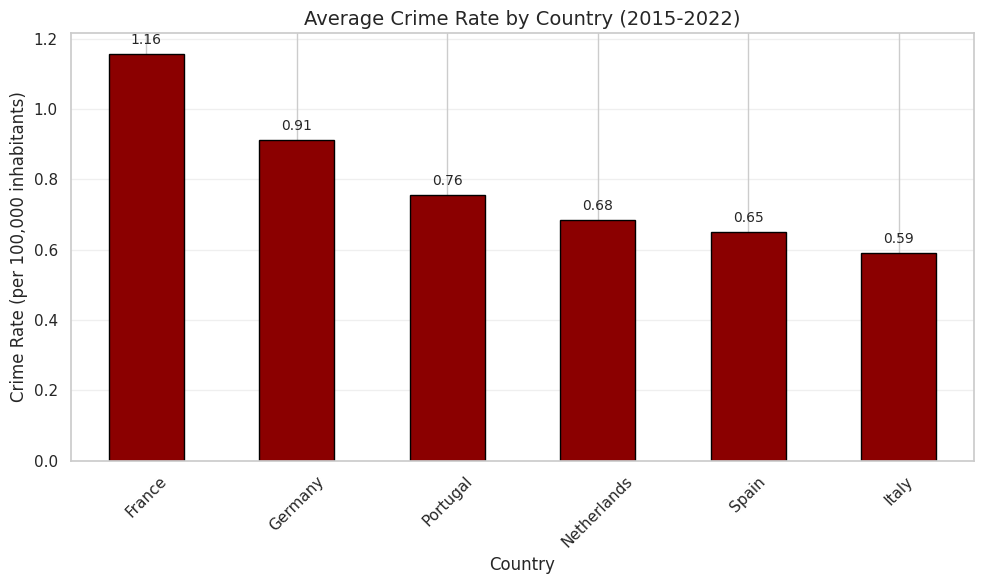


VISUALIZATION 2: Crime Rate Over Time


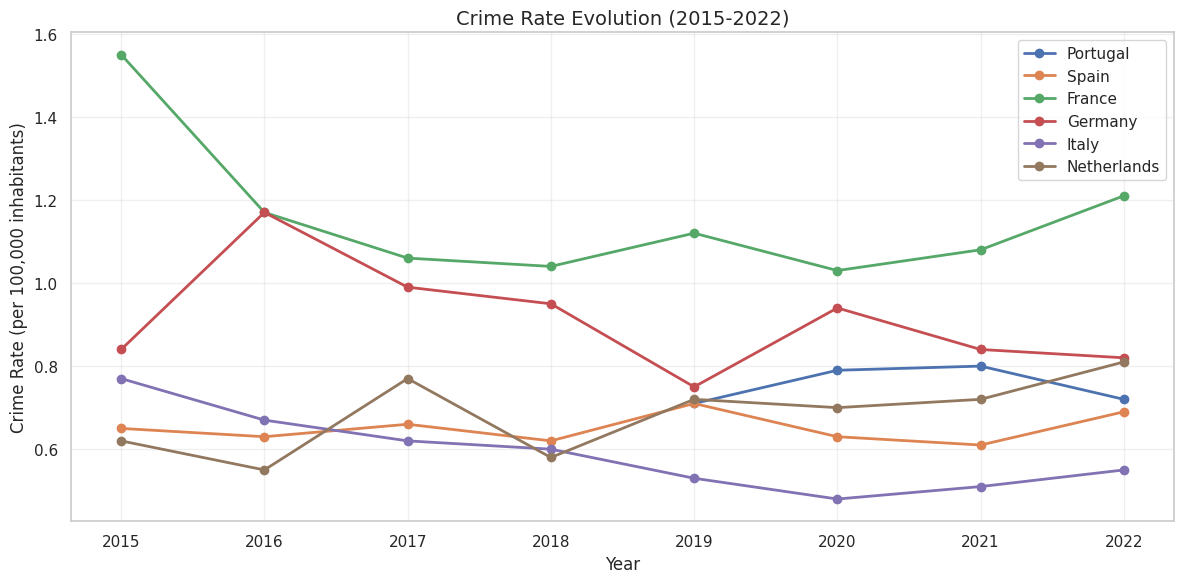


VISUALIZATION 3: Crime vs Unemployment


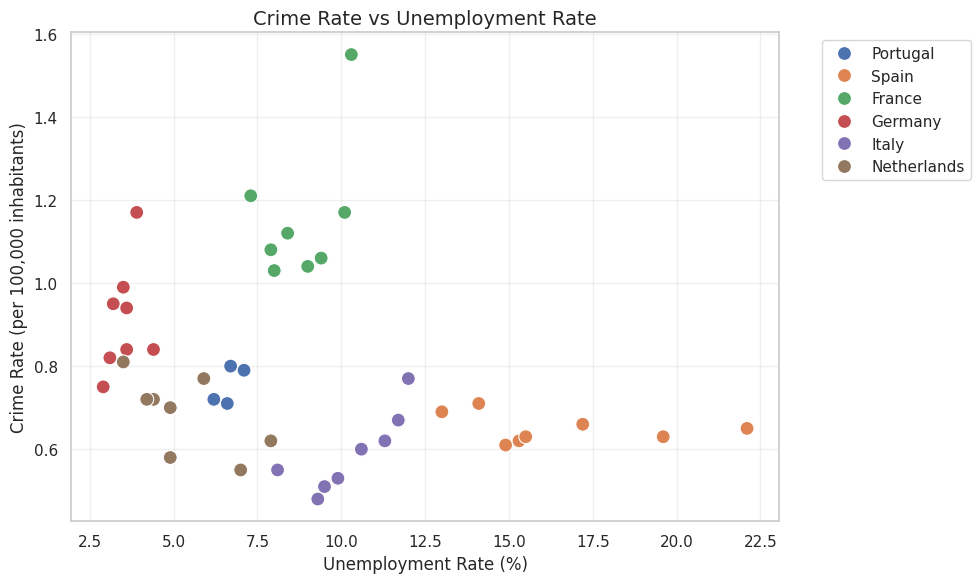


VISUALIZATION 4: Correlation Matrix
                  gdp_per_capita  gini  urban_population  crime_rate  \
gdp_per_capita              1.00 -0.80              0.78        0.20   
gini                       -0.80  1.00             -0.78       -0.21   
urban_population            0.78 -0.78              1.00        0.07   
crime_rate                  0.20 -0.21              0.07        1.00   
unemployment               -0.69  0.56             -0.20       -0.27   

                  unemployment  
gdp_per_capita           -0.69  
gini                      0.56  
urban_population         -0.20  
crime_rate               -0.27  
unemployment              1.00  


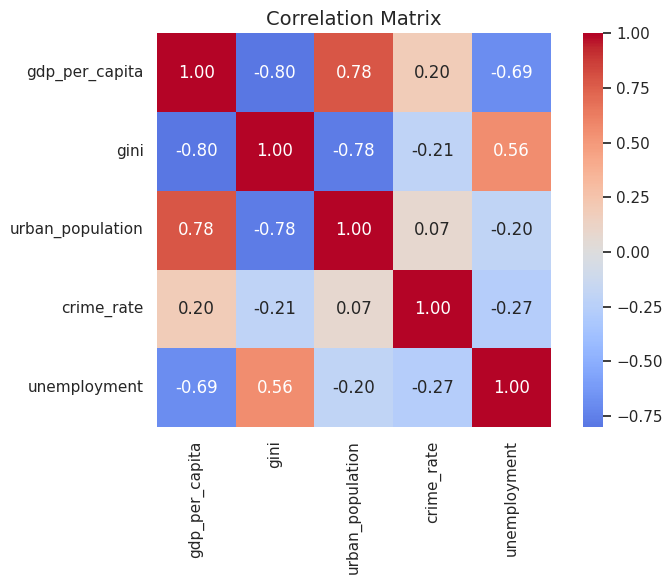


VISUALIZATION 5: GDP vs Crime


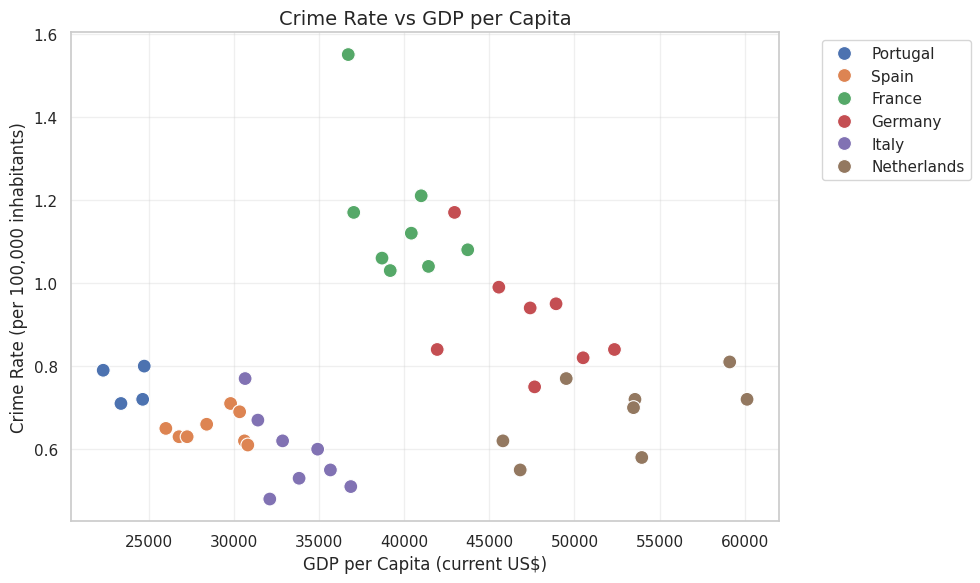


REGRESSION ANALYSIS
                            OLS Regression Results                            
Dep. Variable:             crime_rate   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1.573
Date:                Tue, 30 Jun 2026   Prob (F-statistic):              0.220
Time:                        00:10:52   Log-Likelihood:                 4.8122
No. Observations:                  44   AIC:                            -3.624
Df Residuals:                      41   BIC:                             1.728
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.89

In [29]:
# ============================================================
# ALL VISUALIZATIONS WITH REAL DATA
# ============================================================

# Use df_final, drop rows where crime_rate is missing for fair analysis
df_plot = df_final.dropna(subset=["crime_rate"])

print("="*60)
print("VISUALIZATION 1: Crime Rate by Country")
print("="*60)

crime_by_country = df_plot.groupby("country")["crime_rate"].mean().sort_values(ascending=False)
print(crime_by_country)

plt.figure(figsize=(10, 6))
bars = crime_by_country.plot(kind="bar", color="darkred", edgecolor="black")
plt.title("Average Crime Rate by Country (2015-2022)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
for bar in bars.patches:
    height = bar.get_height()
    if not pd.isna(height):
        bars.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("crime_by_country.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("VISUALIZATION 2: Crime Rate Over Time")
print("="*60)

plt.figure(figsize=(12, 6))
for country in df_plot["country"].unique():
    data = df_plot[df_plot["country"] == country].sort_values("year")
    plt.plot(data["year"], data["crime_rate"], marker="o", label=country, linewidth=2)
plt.title("Crime Rate Evolution (2015-2022)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crime_over_time.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("VISUALIZATION 3: Crime vs Unemployment")
print("="*60)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x="unemployment", y="crime_rate", hue="country", s=100)
plt.title("Crime Rate vs Unemployment Rate", fontsize=14)
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crime_vs_unemployment.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("VISUALIZATION 4: Correlation Matrix")
print("="*60)

numeric_cols = ["gdp_per_capita", "gini", "urban_population", "crime_rate", "unemployment"]
df_corr = df_plot[numeric_cols].dropna()
corr_matrix = df_corr.corr()
print(corr_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("VISUALIZATION 5: GDP vs Crime")
print("="*60)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x="gdp_per_capita", y="crime_rate", hue="country", s=100)
plt.title("Crime Rate vs GDP per Capita", fontsize=14)
plt.xlabel("GDP per Capita (current US$)")
plt.ylabel("Crime Rate (per 100,000 inhabitants)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("crime_vs_gdp.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("REGRESSION ANALYSIS")
print("="*60)

df_reg = df_plot[["crime_rate", "unemployment", "gdp_per_capita"]].dropna()
X = df_reg[["unemployment", "gdp_per_capita"]]
y = df_reg["crime_rate"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

with open("regression_results.txt", "w") as f:
    f.write(model.summary().as_text())

print("\n" + "="*60)
print("WITHIN-COUNTRY CORRELATIONS")
print("="*60)
for country in df_plot["country"].unique():
    subset = df_plot[df_plot["country"] == country]
    if len(subset) >= 3:
        corr = subset["crime_rate"].corr(subset["unemployment"])
        print(f"  {country}: {corr:.2f}")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print("All files generated from real Eurostat & World Bank data.")


In [30]:
from google.colab import files

print("Downloading all generated files...")
files.download("final_dataset.csv")
files.download("crime_by_country.png")
files.download("crime_over_time.png")
files.download("crime_vs_unemployment.png")
files.download("correlation_matrix.png")
files.download("crime_vs_gdp.png")
files.download("regression_results.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>